In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [2]:
nintendo='NTDOY'

/var/folders/ks/l5k0stm95w5b5kn73hwp_8hc0000gn/T/ipykernel_42472/3808477564.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('NTDOY', period='max')
[*********************100%***********************]  1 of 1 completed


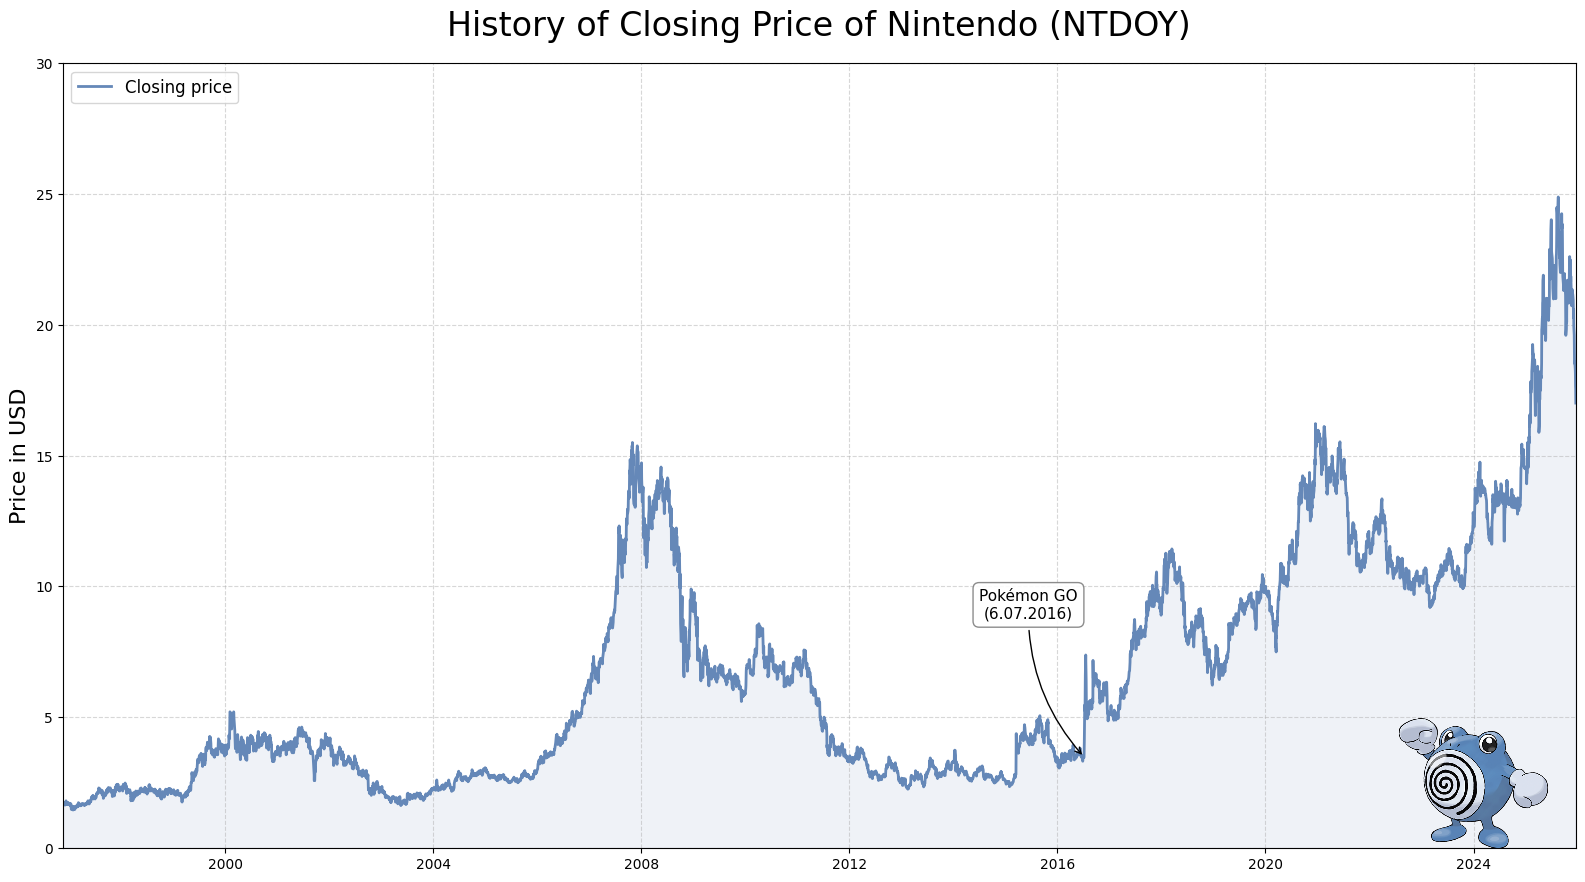

In [5]:
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Pobranie danych
df = yf.download('NTDOY', period='max')
#.. yfinance zwraca dataframe w 2D, a potrzebujemy series w 1D.  Użyjemy .squeeze()
close_price = df['Close'].squeeze() 


fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(df.index, close_price, color='#6588b8', linewidth=2, label='Closing price')
ax.fill_between(df.index, close_price, color='#6588b8', alpha=0.1)

ax.set_title('History of Closing Price of Nintendo (NTDOY)', fontsize=24, pad=20)
ax.set_ylabel('Price in USD', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.set_xlim(df.index.min(), df.index.max()) # Ustawienie limitów X na zakres danych
ax.set_ylim(0,30)

pogo_date = pd.Timestamp('2016-07-06')
price_at_date = close_price.asof(pogo_date)
ax.annotate(
    'Pokémon GO\n(6.07.2016)', # Tekst (używamy \n dla nowej linii)
    xy=(pogo_date, price_at_date),          # Dokąd strzałka celuje (Data, Cena)
    xytext=(-40, 100),                      # Gdzie jest tekst (przesunięcie w punktach: w lewo, w górę)
    textcoords='offset points',             # Interpretacja xytext jako przesunięcia
    arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=.2"), # Styl strzałki
    fontsize=11,
    ha='center', # Wyrównanie tekstu w poziomie
    # Dodajemy białe tło pod tekstem, żeby był czytelny na siatce
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
)

#.... Dodawanie pokemona do wykresu
img = plt.imread('images/images/61.png')
imagebox = OffsetImage(img, zoom=0.25) 
# Oś x to daty -> punkt na współrzędnej X pd.Timestamp
ab = AnnotationBbox(imagebox, xy=(pd.Timestamp('2024-01-01'), 2.45), frameon=False) 
ax.add_artist(ab) 


plt.tight_layout()
plt.savefig('nintendo.png')
plt.show()